# **R/S benchmark — NN validation plots**

Reads the NN models/scaler written by [`04_train_nn.ipynb`](04_train_nn.ipynb) and the stage 1
datasets written by [`01_generate_dataset.ipynb`](01_generate_dataset.ipynb) — makes **no** training
calls, only loads and plots. Three things:

1. predicted vs. true lambda 1 / lambda 2, on the held-out validation split;
2. a spot check — load the model, fix $(R, S)$, sweep $t$, predict; and
3. a KL-divergence check of the NN-predicted GLD against the emulator's own direct fit, at one
   design point — same convention as [`02_train_pce_plot.ipynb`](02_train_pce_plot.ipynb), so the
   two checks can be read side by side: same design point, PCE vs. NN, both against the same real
   data.

Same figure conventions throughout: no titles (captions belong in the LaTeX), configurable
size/fonts/dpi, each saved next to the data it came from.

## 1. Libraries

In [44]:
%matplotlib inline
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import dill
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams.update({
                        'font.family': 'serif',
                        'mathtext.fontset': 'cm',
                        'axes.unicode_minus': False
                    })
from sklearn.model_selection import train_test_split

from functions import *

## 2. Config

`n_latent_samples`, `feature_cols`, `target_cols`, `test_frac` and `random_state` must match
[`04_train_nn.ipynb`](04_train_nn.ipynb) — together they name the files being loaded and rebuild the
same held-out validation split.

In [45]:
n_latent_samples = 2500   # must match stage 3/4 — it names the files being loaded

feature_cols = ['r', 's', 'Time (years)']
target_cols  = ['lambda 1', 'lambda 2']

test_frac    = 0.2   # must match stage 4 — rebuilds the same validation split
random_state = 42    # must match stage 4

fig_size   = (5, 4)      # size of each individual figure, in inches
fig_format = 'png'       # format each figure is saved in ('pdf', 'png', ...)
fig_dpi    = 300         # resolution the figure is saved at (dots per inch)

label_fontsize = 14   # font size of the axis labels
tick_fontsize  = 12   # font size of the tick numbers

xlim = None   # e.g. (-5, 5) to fix the axis; None = auto-scaled to the data, per lambda
ylim = None   # e.g. (-5, 5) to fix the axis; None = auto-scaled to the data, per lambda

## 3. Load the stacked dataset and the trained NN

In [46]:
with open(f'{n_latent_samples}_dataset_nn_benchmark.pkl', 'rb') as f:
    df_nn = dill.load(f)

models = {}
for target in target_cols:
    key = target.replace(' ', '_')
    with open(f'{n_latent_samples}_nn_{key}_model_benchmark.pkl', 'rb') as f:
        models[target] = dill.load(f)

with open(f'{n_latent_samples}_nn_scaler_benchmark.pkl', 'rb') as f:
    scaler = dill.load(f)

print(f"Loaded {len(df_nn)} rows and {len(models)} NN models")
df_nn.head()

Loaded 25000 rows and 2 NN models


,r,s,Time (years),lambda 1,lambda 2,lambda 3,lambda 4
0,5.206907,1.854493,0.0,3.354403,6.357913,0.142157,0.131525
1,5.286790,2.431395,0.0,2.858020,5.292953,0.142157,0.131525
2,5.269668,2.067211,0.0,3.204697,5.916525,0.142157,0.131525
3,5.194718,2.683213,0.0,2.514461,4.938048,0.142157,0.131525
4,5.579349,0.870576,0.0,4.708886,8.263479,0.142157,0.131525


## 4. Predicted vs. true, on the held-out validation split

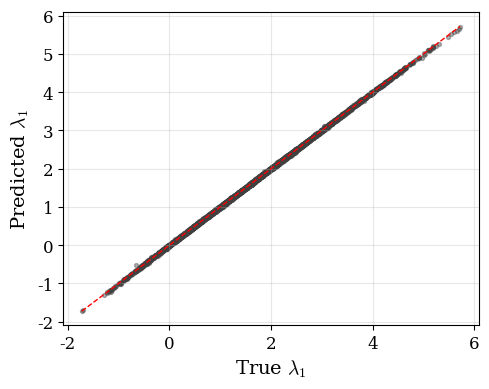

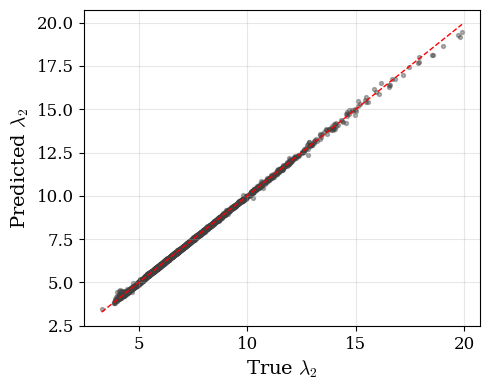

In [47]:
df_clean = df_nn.dropna(subset=target_cols).reset_index(drop=True)
X = df_clean[feature_cols].to_numpy()
y = df_clean[target_cols].to_numpy()
_, x_val, _, y_val = train_test_split(X, y, test_size=test_frac, random_state=random_state)
x_val_s = scaler.transform(x_val)

pkl_name = f'{n_latent_samples}_dataset_nn_benchmark'
figs     = {}

for target in target_cols:
    y_true = y_val[:, target_cols.index(target)]
    y_pred = models[target].predict(x_val_s)
    idx    = target.split(' ')[1]

    fig, ax = plt.subplots(figsize=fig_size)
    ax.scatter(y_true, y_pred, s=8, alpha=0.4, color='0.25')
    lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
    ax.plot(lims, lims, 'r--', lw=1)
    ax.set_xlabel(f'True $\lambda_{{{idx}}}$', fontsize=label_fontsize)
    ax.set_ylabel(f'Predicted $\lambda_{{{idx}}}$', fontsize=label_fontsize)
    ax.tick_params(axis='both', labelsize=tick_fontsize)
    if xlim is not None:
        ax.set_xlim(xlim)
    if ylim is not None:
        ax.set_ylim(ylim)
    ax.grid(True, alpha=0.3)
    fig.tight_layout()

    fig.savefig(f'{pkl_name}_pred_vs_true_lambda_{idx}.{fig_format}', bbox_inches='tight', dpi=fig_dpi)
    figs[target] = fig
    plt.show()

### 4.1 Mesmo gráfico, em português

Para uso no artigo. Salvo como `<pkl_name>_pred_vs_true_lambda_<idx>_pt.<fig_format>`.

In [ ]:
for target in target_cols:
    y_true = y_val[:, target_cols.index(target)]
    y_pred = models[target].predict(x_val_s)
    idx    = target.split(' ')[1]

    fig, ax = plt.subplots(figsize=fig_size)
    ax.scatter(y_true, y_pred, s=8, alpha=0.4, color='0.25')
    lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
    ax.plot(lims, lims, 'r--', lw=1)
    ax.set_xlabel(f'Valor real de $\lambda_{{{idx}}}$', fontsize=label_fontsize)
    ax.set_ylabel(f'Valor previsto de $\lambda_{{{idx}}}$', fontsize=label_fontsize)
    ax.tick_params(axis='both', labelsize=tick_fontsize)
    if xlim is not None:
        ax.set_xlim(xlim)
    if ylim is not None:
        ax.set_ylim(ylim)
    ax.grid(True, alpha=0.3)
    fig.tight_layout()

    fig.savefig(f'{pkl_name}_pred_vs_true_lambda_{idx}_pt.{fig_format}', bbox_inches='tight', dpi=fig_dpi)
    figs[f'{target}_pt'] = fig
    plt.show()

## 5. Spot check — load the model, fix $(R, S)$, sweep $t$

Same demo as the exploratory `old/pce_models.ipynb`: fix a design point and sweep $t$, to see the
predicted lambdas evolve smoothly with time.

In [48]:
r_fixed     = 5.0
s_fixed     = 2.0
times_sweep = np.linspace(0, 100, 10, endpoint=True)

sweep_df = pd.DataFrame({
                           'r':            [r_fixed] * len(times_sweep),
                           's':            [s_fixed] * len(times_sweep),
                           'Time (years)': times_sweep,
                        })

x_sweep_s = scaler.transform(sweep_df[feature_cols].to_numpy())
for target in target_cols:
    sweep_df[f'pred_{target}'] = models[target].predict(x_sweep_s)

sweep_df

,r,s,Time (years),pred_lambda 1,pred_lambda 2
0,5.0,2.0,0.000000,2.995682,6.128036
1,5.0,2.0,11.111111,2.724285,6.205239
2,5.0,2.0,22.222222,2.438676,6.379251
3,5.0,2.0,33.333333,2.173604,6.457705
4,5.0,2.0,44.444444,1.881684,6.593482
5,5.0,2.0,55.555556,1.627654,6.714179
6,5.0,2.0,66.666667,1.344528,6.803352
7,5.0,2.0,77.777778,1.055990,6.910599
8,5.0,2.0,88.888889,0.787778,6.954852
9,5.0,2.0,100.000000,0.499997,7.125649


## 6. NN validation via KL divergence

Spot-checks one design point directly against the NN: the emulator already fits a GLD to its raw
Monte Carlo `g` samples (`lambda 1`-`lambda 4`, in `dataset_unique`/`dataset_full` from
[`01_generate_dataset.ipynb`](01_generate_dataset.ipynb)) — this asks the NN to predict `lambda 1` /
`lambda 2` from `(R, S, t)` alone (`lambda 3`/`lambda 4` are never modelled by the NN, by design —
see [`03_generate_dataset_nn.ipynb`](03_generate_dataset_nn.ipynb)) and scores how close the
resulting GLD is to the real one.

`time_index` and `design_point_index` follow the same convention as
[`02_train_pce_plot.ipynb`](02_train_pce_plot.ipynb) — pick the same values here as there to compare
the PCE and the NN at exactly the same design point.

In [49]:
time_index_kl         = 2   # index into `times_kl` — which stage-1 time step to check
design_point_index_kl = 0   # row index into that time step's dataset_unique_train — which (R, S) to check

times_kl = np.linspace(0, 100, 5, endpoint=True)   # must match stage 1

lambda3_kl = 0.142157   # written by hand — the NN never predicts lambda 3 / lambda 4
lambda4_kl = 0.131525

n_grid_kl = 400   # grid points used to numerically integrate the KL divergence and R²

xlim_kl = None   # e.g. (-5, 15) to fix the g axis; None = auto-scaled to the data
ylim_kl = None   # e.g. (0, 1) to fix the density axis; None = auto-scaled to the data

In [50]:
t_check = times_kl[time_index_kl]

with open(f'{n_latent_samples}_dataset_full_train_{t_check}_benchmark.pkl', 'rb') as f:
    df_full_check = dill.load(f)
with open(f'{n_latent_samples}_dataset_unique_train_{t_check}_benchmark.pkl', 'rb') as f:
    df_unique_check = dill.load(f)

design_point = df_unique_check.iloc[design_point_index_kl]
r_check, s_check = design_point['r'], design_point['s']
g_real = df_full_check.loc[(df_full_check['r'] == r_check) & (df_full_check['s'] == s_check), 'g'].to_numpy()

print(f"Checking t = {t_check:.2f} years, R = {r_check:.3f}, S = {s_check:.3f} ({len(g_real)} raw g samples)")

kl_result_nn = validate_nn_kl_divergence_benchmark(
                                                      models=models,
                                                      scaler=scaler,
                                                      r=r_check,
                                                      s=s_check,
                                                      t=t_check,
                                                      g_real=g_real,
                                                      lambda3=lambda3_kl,
                                                      lambda4=lambda4_kl,
                                                      n_grid=n_grid_kl,
                                                    )

print(f"KL divergence:  {kl_result_nn['kl_divergence']:.5f}")
print(f"KS statistic:   {kl_result_nn['ks_statistic']:.5f}")
print(f"Wasserstein:    {kl_result_nn['wasserstein']:.5f}")
print(f"R2 (PDFs):      {kl_result_nn['r2_pdf']:.5f}")
print(f"Rel. error P5:  {kl_result_nn['rel_err_p5']:+.2%}")
print(f"Rel. error P50: {kl_result_nn['rel_err_p50']:+.2%}")
print(f"Rel. error P95: {kl_result_nn['rel_err_p95']:+.2%}")

Checking t = 50.00 years, R = 5.394, S = 2.305 (2500 raw g samples)
KL divergence:  0.00351
KS statistic:   0.01800
Wasserstein:    0.00529
R2 (PDFs):      0.99801
Rel. error P5:  -0.61%
Rel. error P50: -0.16%
Rel. error P95: +0.27%


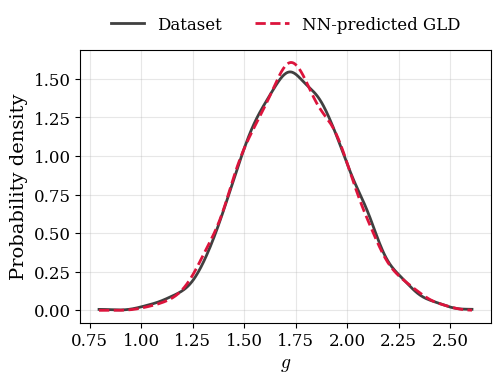

In [51]:
pkl_name_kl = f'{n_latent_samples}_dataset_unique_train_{t_check}_benchmark'

fig, ax = plt.subplots(figsize=fig_size)
ax.plot(kl_result_nn['x_grid'], kl_result_nn['pdf_real'], color='0.25', linewidth=2, label='Dataset')
ax.plot(kl_result_nn['x_grid'], kl_result_nn['pdf_nn'], color='crimson', linewidth=2, linestyle='--', label='NN-predicted GLD')
ax.set_xlabel('$g$', fontsize=label_fontsize)
ax.set_ylabel('Probability density', fontsize=label_fontsize)
ax.tick_params(axis='both', labelsize=tick_fontsize)
if xlim_kl is not None:
    ax.set_xlim(xlim_kl)
if ylim_kl is not None:
    ax.set_ylim(ylim_kl)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.18), ncol=2, fontsize=tick_fontsize, frameon=False)
ax.grid(True, alpha=0.3)
fig.tight_layout()

fig.savefig(f'{pkl_name_kl}_nn_kl_divergence_R{r_check:g}_S{s_check:g}_{t_check}_en.{fig_format}', bbox_inches='tight', dpi=fig_dpi)
plt.show()

### 6.1 Mesmo gráfico, em português

Para uso na dissertação. Salvo como `<pkl_name>_nn_kl_divergence_R<r>_S<s>_pt.<fig_format>`.

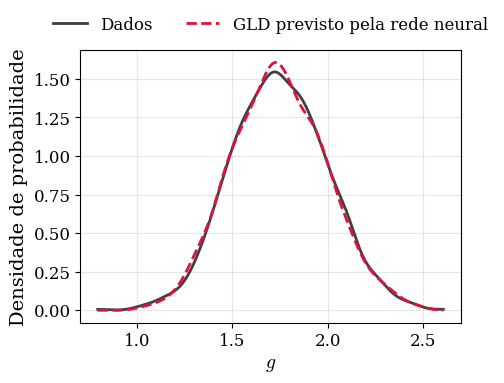

In [52]:
fig, ax = plt.subplots(figsize=fig_size)
ax.plot(kl_result_nn['x_grid'], kl_result_nn['pdf_real'], color='0.25', linewidth=2, label='Dados')
ax.plot(kl_result_nn['x_grid'], kl_result_nn['pdf_nn'], color='crimson', linewidth=2, linestyle='--', label='GLD previsto pela rede neural')
ax.set_xlabel('$g$', fontsize=label_fontsize)
ax.set_ylabel('Densidade de probabilidade', fontsize=label_fontsize)
ax.tick_params(axis='both', labelsize=tick_fontsize)
if xlim_kl is not None:
    ax.set_xlim(xlim_kl)
if ylim_kl is not None:
    ax.set_ylim(ylim_kl)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.18), ncol=2, fontsize=tick_fontsize, frameon=False)
ax.grid(True, alpha=0.3)
fig.tight_layout()

fig.savefig(f'{pkl_name_kl}_nn_kl_divergence_R{r_check:g}_S{s_check:g}_{t_check}_pt.{fig_format}', bbox_inches='tight', dpi=fig_dpi)
plt.show()

### 6.2 Second time check — same $(R, S)$, another $t$

Repeats section 6 at a **second** time step, on the **same** design point. Pick the same
`time_index_kl_b` / `design_point_index_kl` as the `time_index_b` / `design_point_index` used in
[`02_train_pce_plot.ipynb`](02_train_pce_plot.ipynb), and the four checks line up: PCE vs. NN, at
two instants, all against the same raw data.

The design samples are drawn once in [`01_generate_dataset.ipynb`](01_generate_dataset.ipynb) and
reused at every time step, so the index lands on the same $(R, S)$ at both instants — the cell below
prints both and warns if they ever drift apart.

In [53]:
time_index_kl_b = 4   # index into `times_kl` — the second time step to check (section 6 used `time_index_kl`)

lambda3_kl_b = lambda3_kl   # same hand-written lambda 3 / lambda 4 as section 6
lambda4_kl_b = lambda4_kl

In [54]:
t_check_b = times_kl[time_index_kl_b]

with open(f'{n_latent_samples}_dataset_full_train_{t_check_b}_benchmark.pkl', 'rb') as f:
    df_full_check_b = dill.load(f)
with open(f'{n_latent_samples}_dataset_unique_train_{t_check_b}_benchmark.pkl', 'rb') as f:
    df_unique_check_b = dill.load(f)

design_point_b = df_unique_check_b.iloc[design_point_index_kl]
r_check_b, s_check_b = design_point_b['r'], design_point_b['s']

if not (np.isclose(r_check_b, r_check) and np.isclose(s_check_b, s_check)):
    print(f"WARNING: design point {design_point_index_kl} is not the same at both times — "
          f"(R = {r_check:.3f}, S = {s_check:.3f}) at t = {t_check:.2f} vs "
          f"(R = {r_check_b:.3f}, S = {s_check_b:.3f}) at t = {t_check_b:.2f}")

g_real_b = df_full_check_b.loc[(df_full_check_b['r'] == r_check_b) & (df_full_check_b['s'] == s_check_b), 'g'].to_numpy()

print(f"Checking t = {t_check_b:.2f} years, R = {r_check_b:.3f}, S = {s_check_b:.3f} ({len(g_real_b)} raw g samples)")

kl_result_nn_b = validate_nn_kl_divergence_benchmark(
                                                        models=models,
                                                        scaler=scaler,
                                                        r=r_check_b,
                                                        s=s_check_b,
                                                        t=t_check_b,
                                                        g_real=g_real_b,
                                                        lambda3=lambda3_kl_b,
                                                        lambda4=lambda4_kl_b,
                                                        n_grid=n_grid_kl,
                                                      )

print(f"KL divergence:  {kl_result_nn_b['kl_divergence']:.5f}")
print(f"KS statistic:   {kl_result_nn_b['ks_statistic']:.5f}")
print(f"Wasserstein:    {kl_result_nn_b['wasserstein']:.5f}")
print(f"R2 (PDFs):      {kl_result_nn_b['r2_pdf']:.5f}")
print(f"Rel. error P5:  {kl_result_nn_b['rel_err_p5']:+.2%}")
print(f"Rel. error P50: {kl_result_nn_b['rel_err_p50']:+.2%}")
print(f"Rel. error P95: {kl_result_nn_b['rel_err_p95']:+.2%}")

Checking t = 100.00 years, R = 5.394, S = 2.305 (2500 raw g samples)
KL divergence:  0.00318
KS statistic:   0.01960
Wasserstein:    0.00740
R2 (PDFs):      0.99551
Rel. error P5:  -46.78%
Rel. error P50: -2.05%
Rel. error P95: -0.18%


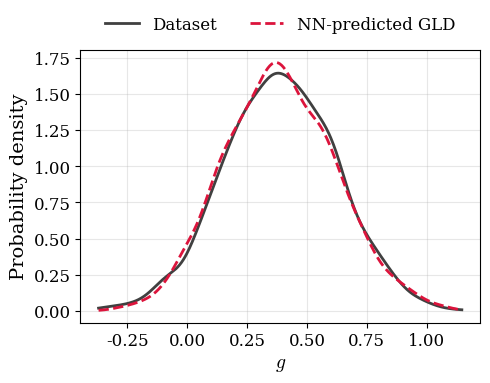

In [55]:
pkl_name_kl_b = f'{n_latent_samples}_dataset_unique_train_{t_check_b}_benchmark'

fig, ax = plt.subplots(figsize=fig_size)
ax.plot(kl_result_nn_b['x_grid'], kl_result_nn_b['pdf_real'], color='0.25', linewidth=2, label='Dataset')
ax.plot(kl_result_nn_b['x_grid'], kl_result_nn_b['pdf_nn'], color='crimson', linewidth=2, linestyle='--', label='NN-predicted GLD')
ax.set_xlabel('$g$', fontsize=label_fontsize)
ax.set_ylabel('Probability density', fontsize=label_fontsize)
ax.tick_params(axis='both', labelsize=tick_fontsize)
if xlim_kl is not None:
    ax.set_xlim(xlim_kl)
if ylim_kl is not None:
    ax.set_ylim(ylim_kl)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.18), ncol=2, fontsize=tick_fontsize, frameon=False)
ax.grid(True, alpha=0.3)
fig.tight_layout()

fig.savefig(f'{pkl_name_kl_b}_nn_kl_divergence_R{r_check_b:g}_S{s_check_b:g}_{t_check_b}_en.{fig_format}', bbox_inches='tight', dpi=fig_dpi)
plt.show()

### 6.3 Mesmo gráfico, em português — segundo tempo

Salvo como `<pkl_name_kl_b>_nn_kl_divergence_R<r>_S<s>_<t>_pt.<fig_format>`.

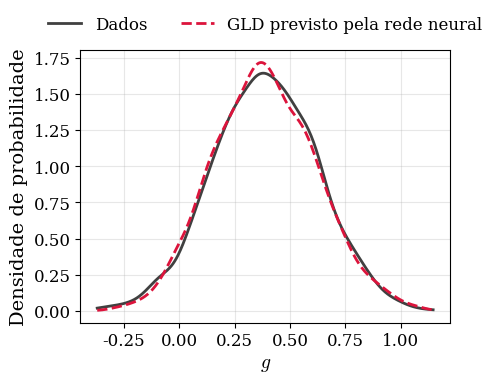

In [56]:
fig, ax = plt.subplots(figsize=fig_size)
ax.plot(kl_result_nn_b['x_grid'], kl_result_nn_b['pdf_real'], color='0.25', linewidth=2, label='Dados')
ax.plot(kl_result_nn_b['x_grid'], kl_result_nn_b['pdf_nn'], color='crimson', linewidth=2, linestyle='--', label='GLD previsto pela rede neural')
ax.set_xlabel('$g$', fontsize=label_fontsize)
ax.set_ylabel('Densidade de probabilidade', fontsize=label_fontsize)
ax.tick_params(axis='both', labelsize=tick_fontsize)
if xlim_kl is not None:
    ax.set_xlim(xlim_kl)
if ylim_kl is not None:
    ax.set_ylim(ylim_kl)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.18), ncol=2, fontsize=tick_fontsize, frameon=False)
ax.grid(True, alpha=0.3)
fig.tight_layout()

fig.savefig(f'{pkl_name_kl_b}_nn_kl_divergence_R{r_check_b:g}_S{s_check_b:g}_{t_check_b}_pt.{fig_format}', bbox_inches='tight', dpi=fig_dpi)
plt.show()

### 6.4 The two times side by side

The same $(R, S)$ at both instants, in one table and one figure — the NN counterpart of section 4.6
of [`02_train_pce_plot.ipynb`](02_train_pce_plot.ipynb).

In [57]:
stat_keys = {
                'KL':             'kl_divergence',
                'KS':             'ks_statistic',
                'Wasserstein':    'wasserstein',
                'R2 (PDF)':       'r2_pdf',
                'Rel. error P5':  'rel_err_p5',
                'Rel. error P50': 'rel_err_p50',
                'Rel. error P95': 'rel_err_p95',
            }

two_times_nn = pd.DataFrame([
                                {'Time (years)': t_c, 'r': r_c, 's': s_c,
                                 **{label: res[key] for label, key in stat_keys.items()}}
                                for t_c, r_c, s_c, res in [(t_check,   r_check,   s_check,   kl_result_nn),
                                                           (t_check_b, r_check_b, s_check_b, kl_result_nn_b)]
                            ])

two_times_nn

,Time (years),r,s,KL,KS,Wasserstein,R2 (PDF),Rel. error P5,Rel. error P50,Rel. error P95
0,50.0,5.394279,2.305431,0.003508,0.0180,0.005289,0.998005,-0.006079,-0.001581,0.002687
1,100.0,5.394279,2.305431,0.003178,0.0196,0.007396,0.995511,-0.467767,-0.020468,-0.001804


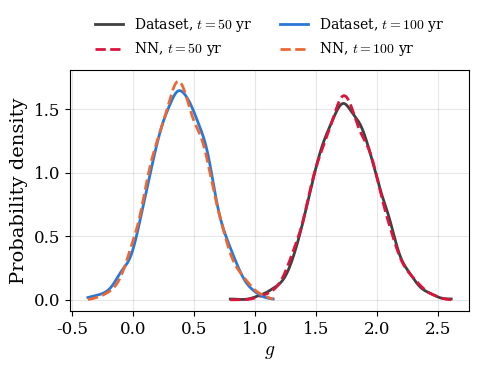

In [58]:
fig, ax = plt.subplots(figsize=fig_size)
ax.plot(kl_result_nn['x_grid'],   kl_result_nn['pdf_real'],   color='0.25',    linewidth=2,                 label=f'Dataset, $t = {t_check:g}$ yr')
ax.plot(kl_result_nn['x_grid'],   kl_result_nn['pdf_nn'],     color='crimson', linewidth=2, linestyle='--', label=f'NN, $t = {t_check:g}$ yr')
ax.plot(kl_result_nn_b['x_grid'], kl_result_nn_b['pdf_real'], color='#2a78d6', linewidth=2,                 label=f'Dataset, $t = {t_check_b:g}$ yr')
ax.plot(kl_result_nn_b['x_grid'], kl_result_nn_b['pdf_nn'],   color='#eb6834', linewidth=2, linestyle='--', label=f'NN, $t = {t_check_b:g}$ yr')
ax.set_xlabel('$g$', fontsize=label_fontsize)
ax.set_ylabel('Probability density', fontsize=label_fontsize)
ax.tick_params(axis='both', labelsize=tick_fontsize)
if xlim_kl is not None:
    ax.set_xlim(xlim_kl)
if ylim_kl is not None:
    ax.set_ylim(ylim_kl)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.28), ncol=2, fontsize=tick_fontsize - 2, frameon=False)
ax.grid(True, alpha=0.3)
fig.tight_layout()

fig.savefig(f'{n_latent_samples}_nn_kl_divergence_R{r_check:g}_S{s_check:g}_t{t_check:g}_vs_t{t_check_b:g}_en.{fig_format}', bbox_inches='tight', dpi=fig_dpi)
plt.show()

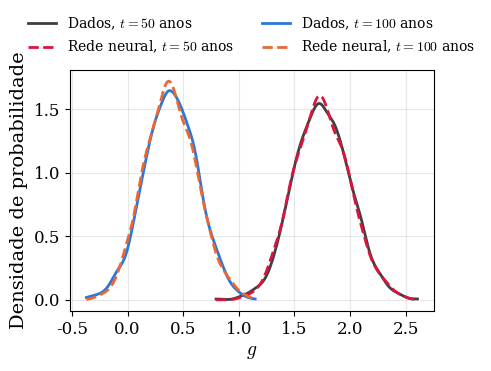

In [59]:
fig, ax = plt.subplots(figsize=fig_size)
ax.plot(kl_result_nn['x_grid'],   kl_result_nn['pdf_real'],   color='0.25',    linewidth=2,                 label=f'Dados, $t = {t_check:g}$ anos')
ax.plot(kl_result_nn['x_grid'],   kl_result_nn['pdf_nn'],     color='crimson', linewidth=2, linestyle='--', label=f'Rede neural, $t = {t_check:g}$ anos')
ax.plot(kl_result_nn_b['x_grid'], kl_result_nn_b['pdf_real'], color='#2a78d6', linewidth=2,                 label=f'Dados, $t = {t_check_b:g}$ anos')
ax.plot(kl_result_nn_b['x_grid'], kl_result_nn_b['pdf_nn'],   color='#eb6834', linewidth=2, linestyle='--', label=f'Rede neural, $t = {t_check_b:g}$ anos')
ax.set_xlabel('$g$', fontsize=label_fontsize)
ax.set_ylabel('Densidade de probabilidade', fontsize=label_fontsize)
ax.tick_params(axis='both', labelsize=tick_fontsize)
if xlim_kl is not None:
    ax.set_xlim(xlim_kl)
if ylim_kl is not None:
    ax.set_ylim(ylim_kl)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.28), ncol=2, fontsize=tick_fontsize - 2, frameon=False)
ax.grid(True, alpha=0.3)
fig.tight_layout()

fig.savefig(f'{n_latent_samples}_nn_kl_divergence_R{r_check:g}_S{s_check:g}_t{t_check:g}_vs_t{t_check_b:g}_pt.{fig_format}', bbox_inches='tight', dpi=fig_dpi)
plt.show()

## 7. Spaghetti comparison — simulated behaviour vs. emulated behaviour

The end-to-end check: pick a design point $(R, S)$ that **exists in the stage-1 dataset**, and put the
simulator's own realizations of $g$ side by side with what the emulator produces at the same point.
Uses the **same** `design_point_index_kl` as section 6 above, so this figure and the KL-divergence
checks (and `02_train_pce_plot.ipynb`) are all anchored to the same $(R, S)$.

One caveat governs how the figure must be read. The stage-1 datasets draw fresh latent variables at
every time step, so the stored realizations are **independent marginals**, not trajectories — the
simulator side has no paths to draw. It is therefore shown as its empirical quantiles at each
simulated instant (markers), while the emulator side, which *is* continuous in time, is shown both as
bands and as individual paths.

Those emulated paths are **comonotonic**: one quantile level $u$ per path, held fixed across time, so
$g_i(t) = Q(u_i;\, \boldsymbol{\lambda}(t))$. That is the same construction the RUL stage uses, and it
is what makes a path monotonic whenever the marginals drift monotonically. Sampling each instant
independently instead would produce paths that wander up and down — impossible for a monotonically
degrading process, and visible at a glance in exactly this plot.

In [60]:
from functions import gld_quantile_at_u

n_paths      = 60     # emulated trajectories drawn on top of the bands
n_time_fine  = 200    # resolution of the continuous time axis
q_lo, q_hi   = 5, 95  # band limits, in percent

# same (R, S) as section 6 above: design_point_index_kl, read from the same dataset_unique_train,
# so the spaghetti plot lines up with the KL-divergence checks and with 02_train_pce_plot.ipynb
times_sp = np.linspace(0, times_kl[-1], len(times_kl))
with open(f'{n_latent_samples}_dataset_unique_train_{times_sp[0]}_benchmark.pkl', 'rb') as f:
    df_unique_probe = dill.load(f)

r_sp, s_sp = df_unique_probe.iloc[design_point_index_kl][['r', 's']]
print(f'design point {design_point_index_kl}:  R = {r_sp:.4f},  S = {s_sp:.4f}')
print(f'{len(df_unique_probe)} design points available in the stage-1 dataset')

design point 0:  R = 5.3943,  S = 2.3054
2000 design points available in the stage-1 dataset


In [61]:
# ---- simulator side: empirical quantiles of g at each simulated instant ----
sim_q = []
for t in times_sp:
    with open(f'{n_latent_samples}_dataset_full_train_{t}_benchmark.pkl', 'rb') as f:
        df_t = dill.load(f)
    g_t = df_t.loc[np.isclose(df_t['r'], r_sp) & np.isclose(df_t['s'], s_sp), 'g'].values
    sim_q.append({'t': t, 'n': len(g_t),
                  'lo': np.percentile(g_t, q_lo), 'med': np.median(g_t),
                  'hi': np.percentile(g_t, q_hi)})
sim_q = pd.DataFrame(sim_q)

# ---- emulator side: NN -> lambdas -> GLD, continuous in time ----
t_fine   = np.linspace(times_sp[0], times_sp[-1], n_time_fine)
x_query  = scaler.transform(np.column_stack([np.full_like(t_fine, r_sp),
                                             np.full_like(t_fine, s_sp), t_fine]))
lam1     = models['lambda 1'].predict(x_query)
lam2     = models['lambda 2'].predict(x_query)
lam3     = float(df_nn['lambda 3'].mean())
lam4     = float(df_nn['lambda 4'].mean())

emu = np.array([gld_quantile_at_u([l1, l2, lam3, lam4], np.array([q_lo / 100, 0.5, q_hi / 100]))
                for l1, l2 in zip(lam1, lam2)])

# comonotonic paths: one quantile level per path, fixed in time
u_paths = np.random.default_rng(random_state).uniform(1e-9, 1 - 1e-9, n_paths)
paths   = np.array([gld_quantile_at_u([l1, l2, lam3, lam4], u_paths)
                    for l1, l2 in zip(lam1, lam2)])

frac_mono = (np.diff(paths, axis=0) <= 1e-9).all(axis=0).mean() * 100
print(f'emulated paths that are monotonically decreasing: {frac_mono:.1f}%')
print(f'simulator realizations per instant: {sim_q["n"].iloc[0]}')

emulated paths that are monotonically decreasing: 100.0%
simulator realizations per instant: 2500


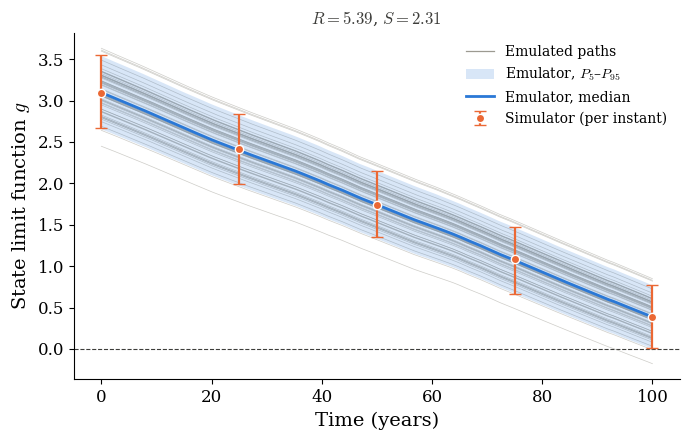

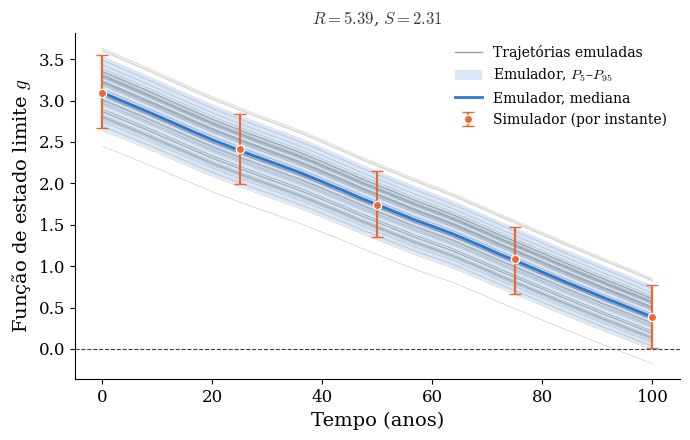

In [62]:
def spaghetti_compare(lang='en', save=True):
    L = {'en': dict(x='Time (years)', y='State limit function $g$',
                    band=f'Emulator, $P_{{{q_lo}}}$–$P_{{{q_hi}}}$', med='Emulator, median',
                    path='Emulated paths', sim='Simulator (per instant)',
                    ttl=f'$R = {r_sp:.2f}$, $S = {s_sp:.2f}$'),
         'pt': dict(x='Tempo (anos)', y='Função de estado limite $g$',
                    band=f'Emulador, $P_{{{q_lo}}}$–$P_{{{q_hi}}}$', med='Emulador, mediana',
                    path='Trajetórias emuladas', sim='Simulador (por instante)',
                    ttl=f'$R = {r_sp:.2f}$, $S = {s_sp:.2f}$')}[lang]

    fig, ax = plt.subplots(figsize=(7.0, 4.5))
    ax.plot(t_fine, paths, color='#9c9a91', linewidth=0.5, alpha=0.5, zorder=1)
    ax.plot([], [], color='#9c9a91', linewidth=0.9, label=L['path'])
    ax.fill_between(t_fine, emu[:, 0], emu[:, 2], color='#2a78d6', alpha=0.18,
                    linewidth=0, label=L['band'], zorder=2)
    ax.plot(t_fine, emu[:, 1], color='#2a78d6', linewidth=2.0, label=L['med'], zorder=3)
    ax.errorbar(sim_q['t'], sim_q['med'],
                yerr=[sim_q['med'] - sim_q['lo'], sim_q['hi'] - sim_q['med']],
                fmt='o', color='#eb6834', markersize=6, markeredgecolor='white',
                markeredgewidth=1.0, elinewidth=1.6, capsize=4, label=L['sim'], zorder=4)
    ax.axhline(0.0, color='#3d3d3a', linewidth=0.8, linestyle='--', zorder=0)

    ax.set_xlabel(L['x'], fontsize=label_fontsize)
    ax.set_ylabel(L['y'], fontsize=label_fontsize)
    ax.set_title(L['ttl'], fontsize=label_fontsize - 2, color='#3d3d3a')
    ax.tick_params(labelsize=tick_fontsize)
    ax.legend(frameon=False, fontsize=tick_fontsize - 2, loc='best')
    for side in ('top', 'right'):
        ax.spines[side].set_visible(False)
    fig.tight_layout()

    if save:
        fig.savefig(f'z_spaghetti_compare_{lang}.{fig_format}', dpi=fig_dpi, bbox_inches='tight')
    return fig


for lang in ('en', 'pt'):
    spaghetti_compare(lang)
plt.show()

In [63]:
# quantitative counterpart of the figure: emulator vs simulator at each simulated instant
rows = []
for _, row in sim_q.iterrows():
    j   = int(np.argmin(np.abs(t_fine - row['t'])))
    rng_band = row['hi'] - row['lo']
    rows.append({'t (years)': row['t'],
                 'sim P50': row['med'], 'emu P50': emu[j, 1],
                 'err P50 (%)': abs(emu[j, 1] - row['med']) / rng_band * 100,
                 'err P5 (%)':  abs(emu[j, 0] - row['lo']) / rng_band * 100,
                 'err P95 (%)': abs(emu[j, 2] - row['hi']) / rng_band * 100})

print('Quantile errors normalised by the simulator P5-P95 spread at each instant.\n')
pd.DataFrame(rows).round(3)

Quantile errors normalised by the simulator P5-P95 spread at each instant.



,t (years),sim P50,emu P50,err P50 (%),err P5 (%),err P95 (%)
0,0.0,3.091,3.097,0.644,1.788,1.386
1,25.0,2.417,2.395,2.575,2.728,1.644
2,50.0,1.742,1.736,0.706,2.394,0.557
3,75.0,1.081,1.074,0.814,1.397,0.415
4,100.0,0.389,0.385,0.578,1.444,0.608
